## Experiment Design (Power Analysis)

Computing the required sample size using power analysis, to ensure we have enough users

In [2]:
import numpy as np

np.random.seed(42)

alpha = 0.05
power = 0.80
ctr_control = 0.08 # baseline ctr
min_lift = 0.02  # baseline lift

ctr_treatment = ctr_control + min_lift

### Effect size (Cohen's h)

In [3]:
from statsmodels.stats.power import NormalIndPower

effect_size = 2 * (np.arcsin(np.sqrt(ctr_treatment)) - np.arcsin(np.sqrt(ctr_control)))

analysis = NormalIndPower()
required_n = int(np.ceil(analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha, alternative='larger')))

print(f"Required users per variant: {required_n}")
print(f"Total users required: {required_n * 2}\n")

Required users per variant: 2525
Total users required: 5050



## Event Simulation (Users, Model, Responses)

Assigning A/B variants and simulating model latency + clicks

In [4]:
MODEL_CONFIG = {
    "control": {"ctr": ctr_control, "latency": 35},
    "treatment": {"ctr": ctr_treatment, "latency": 45}
}

In [5]:
import uuid
from datetime import datetime, timedelta

def assign_variant():
    return np.random.choice(["control", "treatment"], p=[0.5, 0.5])

def random_timestamp():
    base = datetime.now()
    return base + timedelta(minutes=np.random.randint(0, 60))
    
def simulate_users(n_users, start_index=0):
    records = []
    for i in range(n_users):
        user_id = f"user_{start_index + i}"
        variant = assign_variant()
        config = MODEL_CONFIG[variant]

        # Assignment
        records.append({
            "event_id": str(uuid.uuid4()),
            "event_type": "assignment",
            "user_id": user_id,
            "variant": variant,
            "timestamp": random_timestamp(),
            "latency_ms": None,
            "clicked": None
        })

        # Inference
        latency = max(5, int(np.random.normal(config["latency"], 8)))
        records.append({
            "event_id": str(uuid.uuid4()),
            "event_type": "inference",
            "user_id": user_id,
            "variant": variant,
            "timestamp": random_timestamp(),
            "latency_ms": latency,
            "clicked": None
        })

        # Response
        click = np.random.binomial(1, config["ctr"])
        records.append({
            "event_id": str(uuid.uuid4()),
            "event_type": "response",
            "user_id": user_id,
            "variant": variant,
            "timestamp": random_timestamp(),
            "latency_ms": None,
            "clicked": click
        })

    return pd.DataFrame(records)

### Running simulation to generate users in batches until power is met

In [6]:
import pandas as pd

batch_size = 2000
all_events = pd.DataFrame()
total_users = 0

while True:
    new_events = simulate_users(batch_size, start_index=total_users)
    all_events = pd.concat([all_events, new_events], ignore_index=True)
    total_users += batch_size

    # Count users per variant
    assignments = all_events[all_events.event_type == "assignment"]
    counts = assignments.groupby("variant")["user_id"].nunique()

    min_users = counts.min()

    print(f"Users so far: {total_users} | Min per variant: {min_users}")

    if min_users >= required_n:
        print("\nEnough data collected!\n")
        break

Users so far: 2000 | Min per variant: 997
Users so far: 4000 | Min per variant: 1959
Users so far: 6000 | Min per variant: 2993

Enough data collected!



## Aggregating to build metrics from event-level data

In [7]:
responses = all_events[all_events.event_type == "response"]
inference = all_events[all_events.event_type == "inference"]

In [8]:
# Building CTR, impressions, users and latency metrics
metrics = responses.groupby("variant").agg(
    users=("user_id", "nunique"),
    clicks=("clicked", "sum"),
    impressions=("user_id", "count")
)

metrics["ctr"] = metrics["clicks"] / metrics["impressions"]

latency = inference.groupby("variant")["latency_ms"].sum()
metrics = metrics.merge(latency, on="variant")
metrics["avg_latency"] = metrics["latency_ms"] / metrics["impressions"]

print(metrics)

           users  clicks  impressions       ctr  latency_ms  avg_latency
variant                                                                 
control     2993   251.0         2993  0.083862    102894.0    34.378216
treatment   3007   316.0         3007  0.105088    134340.0    44.675757


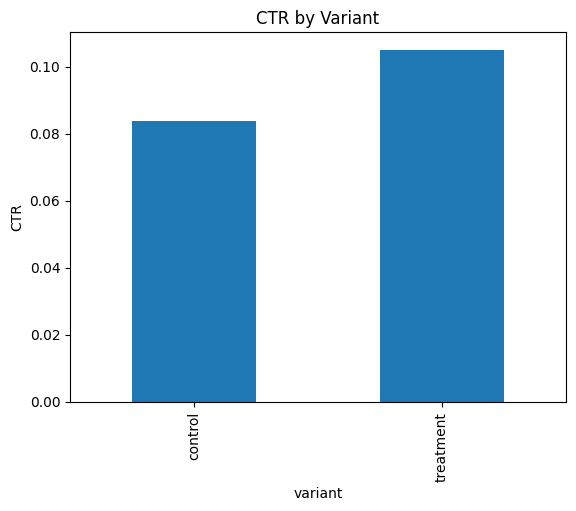

In [23]:
import matplotlib.pyplot as plt

# CTR plot
metrics["ctr"].plot(kind="bar")
plt.title("CTR by Variant")
plt.ylabel("CTR")
plt.show()

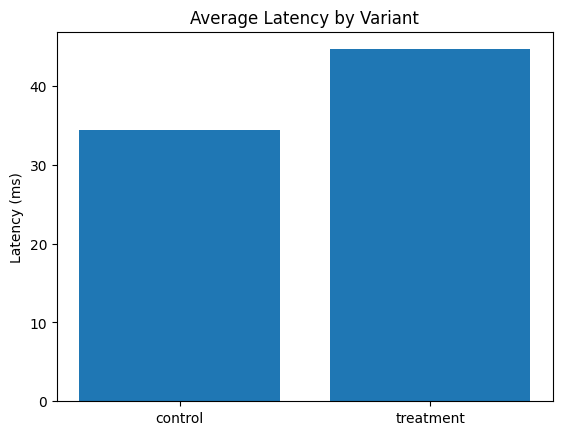

In [38]:
# Latency plot
plt.bar(metrics.index, metrics["avg_latency"])
plt.title("Average Latency by Variant")
plt.ylabel("Latency (ms)")
plt.show()

In [11]:
control = metrics.loc["control"]
treatment = metrics.loc["treatment"]

In [12]:
print(f"CTR Control: {control.ctr:.4f}")
print(f"CTR Treatment: {treatment.ctr:.4f}")

CTR Control: 0.0839
CTR Treatment: 0.1051


At first glance, treatment looks better with higher CTR

### Lift calculation

In [13]:
absolute_lift = treatment.ctr - control.ctr
print(f"Lift: {absolute_lift:.4%}")

Lift: 2.1226%


For every 100 users, ~2 more users click with treatment

## Statistical Testing
### Z-test

In [14]:
from statsmodels.stats.proportion import proportions_ztest

stat, p_value = proportions_ztest(
    [treatment.clicks, control.clicks],
    [treatment.users, control.users],
    alternative='larger'
)

In [15]:
print(f"P-value: {p_value:.6f}")

P-value: 0.002475


P-value (0.002475) < Alpha (0.05). Result is statistically significant

### Confidence intervals

In [16]:
from scipy.stats import norm

se = np.sqrt(
    (control.ctr * (1 - control.ctr) / control.users) +
    (treatment.ctr * (1 - treatment.ctr) / treatment.users)
)

z = norm.ppf(0.95)
ci_lower = absolute_lift - z * se
ci_upper = absolute_lift + z * se

In [17]:
print(f"95% CI: [{ci_lower:.4%}, {ci_upper:.4%}]")

95% CI: [0.8813%, 3.3638%]


- Worst case, +0.88% improvement
- Best case → +3.36% improvement
- Entire interval > 0

This confirms the treatment is very likely better

## Guardrail Check

In [18]:
latency_regression = treatment.avg_latency > control.avg_latency * 1.25
print(f"Latency regression: {latency_regression}")

Latency regression: True


This shows that treatment is >25% slower than control

## Final Decision

In [19]:
print(f"CTR Control: {control.ctr:.4f}")
print(f"CTR Treatment: {treatment.ctr:.4f}")
print(f"Lift: {absolute_lift:.4%}")
print(f"P-value: {p_value:.6f}")
print(f"95% CI: [{ci_lower:.4%}, {ci_upper:.4%}]")
print(f"Latency regression: {latency_regression}")

CTR Control: 0.0839
CTR Treatment: 0.1051
Lift: 2.1226%
P-value: 0.002475
95% CI: [0.8813%, 3.3638%]
Latency regression: True


In [20]:
ship = (
    (p_value < alpha) and
    (absolute_lift >= min_lift) and
    not latency_regression
)

print("Decision:", "SHIP" if ship else "DO NOT SHIP")

Decision: DO NOT SHIP


#### Conclusion

The model works, but it’s too slow to deploy safely.

The treatment significantly improves CTR by about 2.1%, and the result is statistically robust with a low p-value and a positive confidence interval. However, it introduces a latency regression beyond our acceptable threshold, so I would not ship it as-is. 

##### Next steps
- Optimize the model to reduce latency (model compression, caching)
- Relax latency constraints depending on business priorities
- Segment analysis. Maybe high-value users benefit more

In [21]:
all_events.to_csv("events.csv", index=False)